In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 1.7 MB/s eta 0:00:00a 0:00:01m


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, classification_report, confusion_matrix, 
                             roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("Set2")

In [4]:
df = pd.read_csv('school_vacancies_clean.csv')
df

,id,stateRegionCode,vacancyName,codeProfession,codeProfessionalSphere,professionalSphereName,vacancyAddress,vacancyAddressHouse,geo,salary,...,JobRole_Режим гибкого рабочего времени,JobRole_Сменная работа,JobRole_Временная,JobRole_Полная занятость,JobRole_Сезонная,JobRole_Стажировка,JobRole_Удалённая,JobRole_Частичная занятость,school_suitability_index,federal_district
0,eeaddde8-f5d0-11f0-ba7d-9959eb3311ba,3100000000000,Уборщик производственных и служебных помещений,192624.0,Education,"Образование, наука","Белгородская область, Город Губкин, Мичурина у...",дом: ЗД. 21;,"{""latitude"": 51.28298, ""longitude"": 37.529349}",27100,...,0,0,1,0,0,0,0,0,1,Центральный
1,74fb9f78-f533-11f0-a027-0dd543315e5a,5200000000000,Помощник,177874.0,Industry,Производство,"Нижегородская область, Город Нижний Новгород, ...",дом: Д.5;,"{""latitude"": 56.250627, ""longitude"": 43.976396}",28000,...,0,0,0,1,0,0,0,0,0,Приволжский
2,0bb2daf0-e166-11f0-a6fd-690b9f9d74c0,5200000000000,Гардеробщик,116334.0,Culture,"Искусство, культура и развлечения","Нижегородская область, Город Дзержинск, Ленина...",дом: 62;,"{""latitude"": 56.237197, ""longitude"": 43.456541}",27093,...,0,0,0,1,0,0,0,0,0,Приволжский
3,4297f4e9-f68a-11f0-a027-0dd543315e5a,5200000000000,Уборщик производственных и служебных помещений,192588.0,Education,"Образование, наука","Нижегородская область, Город Выкса, Братьев Ба...",дом: ЗД. 3;,"{""latitude"": 55.320565, ""longitude"": 42.151576}",27903,...,0,0,0,1,0,0,0,0,0,Приволжский
4,07e57c50-f6bc-11f0-8628-a3cca5294b78,6800000000000,Подсобный рабочий,167711.0,Industry,Производство,"Тамбовская область, Мордовский район, Промышле...",строение 1,"{""latitude"": 52.133137, ""longitude"": 40.824028}",28571,...,0,0,1,0,0,0,0,0,1,Центральный
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,e02fe0b4-f76f-11f0-ba7d-9959eb3311ba,5200000000000,Подсобный рабочий,167711.0,Communal,"ЖКХ, эксплуатация","Нижегородская область, Город Выкса, Досчатое р...",дом ЗДАН 1,"{""latitude"": 55.378473, ""longitude"": 42.127672}",27093,...,0,0,0,0,0,0,0,1,1,Приволжский
2209,de298c18-0004-11f1-b4ed-438ed61bfb06,3800000000000,Подсобный рабочий,167711.0,ChemicalAndFuelIndustry,"Химическая, нефтехимическая, топливная промышл...","Иркутская область, Город Ангарск, Первый промы...",строение 5,"{""latitude"": 52.562356, ""longitude"": 103.88754}",30642,...,0,0,1,0,0,0,0,0,1,Сибирский
2210,fe989fbc-f2ab-11f0-8628-a3cca5294b78,3800000000000,Подсобный рабочий,167711.0,NotQualification,"Работы, не требующие квалификации","Иркутская область, Город Иркутск, Розы Люксемб...",дом: Д. 184;,"{""latitude"": 52.356439, ""longitude"": 104.15991}",8805,...,0,0,0,1,0,0,0,0,0,Сибирский
2211,fe2217b8-f2cd-11f0-8628-a3cca5294b78,100000000000,Помощник,132479.0,DeskWork,"Административная работа, секретариат, АХО","Республика Адыгея (Адыгея), Тахтамукайский рай...",9/2 офис 1,"{""latitude"": 44.930838, ""longitude"": 38.927675}",27093,...,0,0,0,1,0,0,0,0,0,Южный


Задача: целевой переменной выбираем бинарную school_suitability_index — подходит ли вакансия для школьников. Этот признак создан на основе требований к опыту и типу занятости, показывает подходит ли вакансия для несовершеннолетних.

In [82]:
target = 'school_suitability_index'

In [83]:
features = [
    'exp_scaled',            
    'workPlaces',           
    'latitude',             
    'longitude',           
    'premium_size',         
    'JobRole_Частичная занятость', 
    'JobRole_Временная'     
]

In [84]:
X = df[features].copy()
y = df[target].copy()

In [18]:
valid_idx = y.notna() & (~X[['exp_scaled', 'workPlaces', 'latitude', 'longitude']].isna().any(axis=1))
X = X[valid_idx]
y = y[valid_idx]

In [33]:
if 'premium_size' in X.columns:
    X['premium_size'] = X['premium_size'].fillna(0)

In [35]:
valid_idx = y.notna() & (~X[['exp_scaled', 'workPlaces', 'latitude', 'longitude']].isna().any(axis=1))
X = X[valid_idx]
y = y[valid_idx]

Распределение целевой переменной

In [36]:
y.value_counts()

school_suitability_index
0    1373
1     833
Name: count, dtype: int64

Масштабируем числовые признаки

In [37]:
numeric_features = ['exp_scaled', 'workPlaces', 'latitude', 'longitude', 'premium_size']
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [39]:
X_train.shape

(1764, 7)

In [40]:
X_test.shape

(442, 7)

In [41]:
y_train.value_counts()

school_suitability_index
0    1098
1     666
Name: count, dtype: int64

In [42]:
y_test.value_counts()

school_suitability_index
0    275
1    167
Name: count, dtype: int64

Алгоритмы, выбранные для дальнейшего исследования: 
Логистическая регрессия, так как является базовым алгоритмом для бинарной классификации, будет хороша как бенчмарк для сравнения. Гиперпараметры: C=1.0, solver='lbfgs'. 
Рандом форест, ансамбль устойчивый к переобучению, поможет оценить важность признаков. Гиперпараметры: n_estimators=100, max_depth=10.
XGBOOST, Бустинг, по требованию задания, ысокая точность предсказаний.Гиперпараметры: n_estimators=100, max_depth=6, learning_rate=0.1.

Модель 1: Логистическая регрессия

In [43]:
lr = LogisticRegression(C=1.0, solver='lbfgs', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [44]:
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

In [46]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Accuracy: 0.9977
Precision: 1.0000
Recall: 0.9940
F1-score: 0.9970
ROC-AUC: 0.9980


Модель 2: Случайный лес

In [47]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_jobs=-1, random_state=42)

In [48]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [49]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

Accuracy: 0.9955
Precision: 0.9940
Recall: 0.9940
F1-score: 0.9940
ROC-AUC: 1.0000


Модель 3: Бустинг

In [51]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [52]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

In [53]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

Accuracy: 0.9977
Precision: 1.0000
Recall: 0.9940
F1-score: 0.9970
ROC-AUC: 1.0000


Кроссвалидация

In [54]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [55]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

In [56]:
cv_results = {}

In [57]:
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: F1 = 0.9955 ± 0.0028
Random Forest: F1 = 0.9925 ± 0.0062
XGBoost: F1 = 0.9933 ± 0.0068


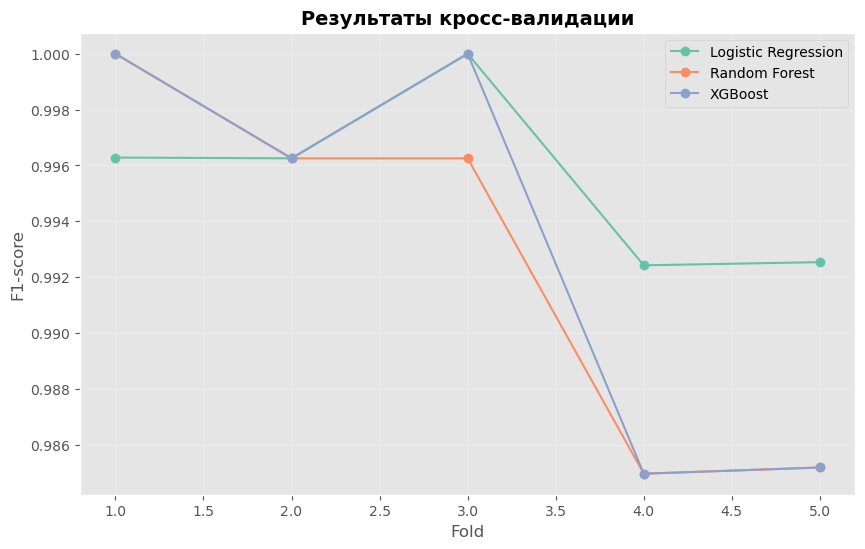

In [63]:
plt.figure(figsize=(10, 6))
for name, results in cv_results.items():
    plt.plot(range(1, 6), results['scores'], marker='o', label=name)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.title('Результаты кросс-валидации', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [59]:
results_df = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_lr),
               recall_score(y_test, y_pred_rf),
               recall_score(y_test, y_pred_xgb)],
    'F1-score': [f1_score(y_test, y_pred_lr),
                 f1_score(y_test, y_pred_rf),
                 f1_score(y_test, y_pred_xgb)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_lr),
                roc_auc_score(y_test, y_proba_rf),
                roc_auc_score(y_test, y_proba_xgb)],
    'CV-F1_mean': [cv_results['Logistic Regression']['mean'],
                   cv_results['Random Forest']['mean'],
                   cv_results['XGBoost']['mean']],
    'CV-F1_std': [cv_results['Logistic Regression']['std'],
                  cv_results['Random Forest']['std'],
                  cv_results['XGBoost']['std']]
})

print(results_df.round(4).to_string(index=False))

             Модель  Accuracy  Precision  Recall  F1-score  ROC-AUC  CV-F1_mean  CV-F1_std
Logistic Regression    0.9977      1.000   0.994     0.997    0.998      0.9955     0.0028
      Random Forest    0.9955      0.994   0.994     0.994    1.000      0.9925     0.0062
            XGBoost    0.9977      1.000   0.994     0.997    1.000      0.9933     0.0068


Лучше всего по метрикам показывается логистическая регрессия, она показывает самую лучшую стабильность, стандартное отклонение при кросс-валидации минимально, модель устойчива к составу обучающей выборки. Лучший баланс между precision и высоким recall. При высоком качестве нет разрыва между обучающими и тестовыми метриками.

In [65]:
coefficients = lr.coef_[0]
norm_importance = np.abs(coefficients) / np.sum(np.abs(coefficients))

In [66]:
feature_importance = pd.DataFrame({
    'Признак': available_features,
    'Коэффициент': coefficients,
    'Важность': norm_importance
}).sort_values('Важность', ascending=False)

In [73]:
feature_importance

,Признак,Коэффициент,Важность
6,JobRole_Временная,7.903465,0.429013
5,JobRole_Частичная занятость,7.116280,0.386283
0,exp_scaled,-2.916812,0.158329
1,workPlaces,0.292532,0.015879
2,latitude,-0.163700,0.008886
3,longitude,-0.023365,0.001268
4,premium_size,0.006281,0.000341


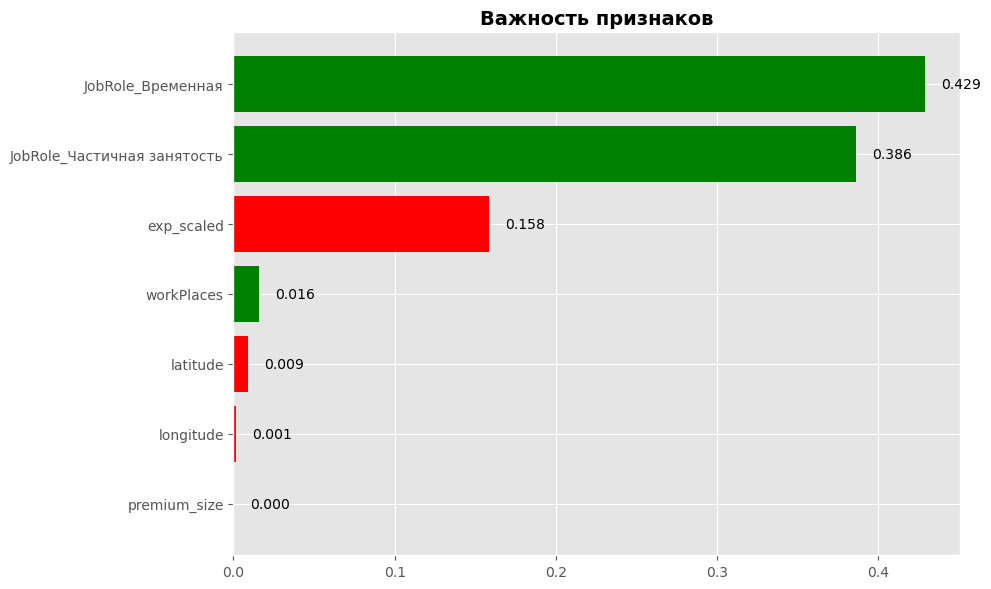

In [144]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'], feature_importance['Важность'], color=colors)
plt.title('Важность признаков', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

for i, (_, row) in enumerate(feature_importance.iterrows()):
    plt.text(row['Важность'] + 0.01, i, f"{row['Важность']:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

В основном, тип занятости является основноым признаком, определяющим принадлежность вакансии к подходящему нам сегменту. Эти два признака вносят 81.5% вклада в предсказательную способность модели. Опыт работы, хотя и имеет отрицательное влияние, играет второстепенную роль. Географические факторы и наличие премии практически не влияют на классификацию.

Регрессия!

In [107]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

In [108]:
def calculate_hourly_rate(row):
    salary = row['salary']
    if pd.isna(salary) or salary == 0:
        return 0
    
    if row['busyType'] == 'Полная занятость':
        hours_per_month = 20 * 8  
    elif row['busyType'] == 'Частичная занятость':
        hours_per_month = 20 * 4   
    elif row['busyType'] in ['Временная', 'Стажировка']:
        hours_per_month = 20 * 6  
    else:
        hours_per_month = 20 * 7   
    
    return salary / hours_per_month if hours_per_month > 0 else 0

In [109]:
df['hourly_rate'] = df.apply(calculate_hourly_rate, axis=1)

In [110]:
df['hourly_rate'].describe()

count    2213.000000
mean      214.326270
std        84.019359
min         6.250000
25%       169.331250
50%       193.521429
75%       236.250000
max       937.500000
Name: hourly_rate, dtype: float64

Задача: целевой переменной выбираем числовую переменую hourly_rate, рассчитанную как отношение зарплаты к количеству рабочих часов в месяц. Выбираем ее так как часовая ставка лучше отражает реальную стоимость труда. Поможет корректно сравнить вакансии с разным графиком работы и имеет более нормальное распределение после преобразования.

In [111]:
target = 'hourly_rate'

Признаки берем те же что и в классификации

In [112]:
features = [
    'exp_scaled',
    'workPlaces',
    'latitude',
    'longitude',
    'premium_size',
    'JobRole_Частичная занятость',
    'JobRole_Временная'
]

In [113]:
X = df[features].copy()
y = df[target].copy()

In [114]:
if 'premium_size' in X.columns:
    X['premium_size'] = X['premium_size'].fillna(0)

In [115]:
valid_idx = y.notna() & (~X[['exp_scaled', 'workPlaces', 'latitude', 'longitude']].isna().any(axis=1))
X = X[valid_idx]
y = y[valid_idx]

In [116]:
y.describe()

count    2206.000000
mean      214.427042
std        84.100511
min         6.250000
25%       169.331250
50%       193.521429
75%       236.859375
max       937.500000
Name: hourly_rate, dtype: float64

In [117]:
numeric_features = ['exp_scaled', 'workPlaces', 'latitude', 'longitude', 'premium_size']
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [119]:
X_train.shape

(1764, 7)

In [120]:
X_test.shape

(442, 7)

In [121]:
y_train.mean()

np.float64(215.6630002497031)

In [122]:
y_test.mean()

np.float64(209.49439573906486)

Выбираем те же алгоритмы регрессии, что и для задачи классификации. Линейная регрессия со стандартными гиперпараметрами, рандом форест с гиперпараметрами n_estimators=100, max_depth=10, бустинг с гиперпараметры: n_estimators=100, max_depth=6, learning_rate=0.1.

Модель 1: линейная регрессия

In [129]:
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)

LinearRegression()

In [130]:
y_pred_lr = lr_reg.predict(X_test)

In [131]:
print(f"R²: {r2_score(y_test, y_pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")

R²: 0.2945
RMSE: 67.34
MAE: 40.05


Модель 2: рандом форест

In [132]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_jobs=-1, random_state=42)

In [133]:
y_pred_rf = rf_reg.predict(X_test)

In [134]:
print(f"R²: {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")

R²: 0.5107
RMSE: 56.08
MAE: 31.09


Модель 3: бустинг

In [135]:
xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [136]:
y_pred_xgb = xgb_reg.predict(X_test)

In [137]:
print(f"R²: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")

R²: 0.5433
RMSE: 54.18
MAE: 31.18


Кроссвалидация

In [138]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [139]:
models_reg = {
    'Linear Regression': lr_reg,
    'Random Forest': rf_reg,
    'XGBoost': xgb_reg
}

In [140]:
cv_results_reg = {}

In [141]:
for name, model in models_reg.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    cv_results_reg[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"{name}: R² = {scores.mean():.4f} ± {scores.std():.4f}")

Linear Regression: R² = 0.3333 ± 0.0942
Random Forest: R² = 0.5243 ± 0.0640
XGBoost: R² = 0.5032 ± 0.0627


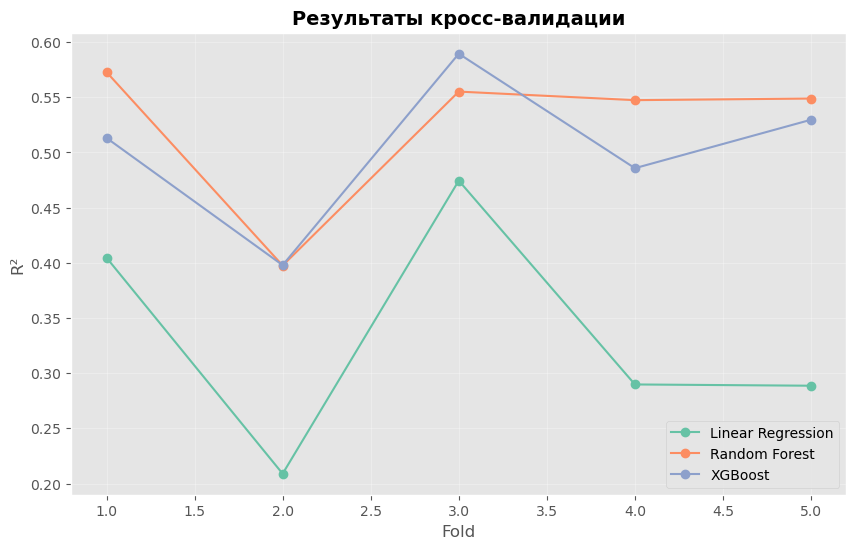

In [143]:
plt.figure(figsize=(10, 6))
for name, results in cv_results_reg.items():
    plt.plot(range(1, 6), results['scores'], marker='o', label=name)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('R²', fontsize=12)
plt.title('Результаты кросс-валидации', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Тут лучшей моделью оказался случайный лес со средним R квадрат = 0.5243. Модель объясняет 52.4% дисперсии целевой переменной, что много, и имееет высокую стабильность на всех фолдах кросс-валидации. Бустинг показывает близкие, но чуть более низкие результаты, на 2 процентных пункта ниже чем лес. Линейная регрессия намного хуже ансамблевых моделей, значит есть нелинейные зависимости в данных.

Проанализируем важность признаков у случайного леса

In [147]:
importance_rf = pd.DataFrame({
    'Признак': available_features,
    'Важность': rf_reg.feature_importances_
}).sort_values('Важность', ascending=False)

importance_rf

,Признак,Важность
3,longitude,0.326383
5,JobRole_Частичная занятость,0.272520
2,latitude,0.238533
6,JobRole_Временная,0.066745
0,exp_scaled,0.055434
1,workPlaces,0.031967
4,premium_size,0.008418


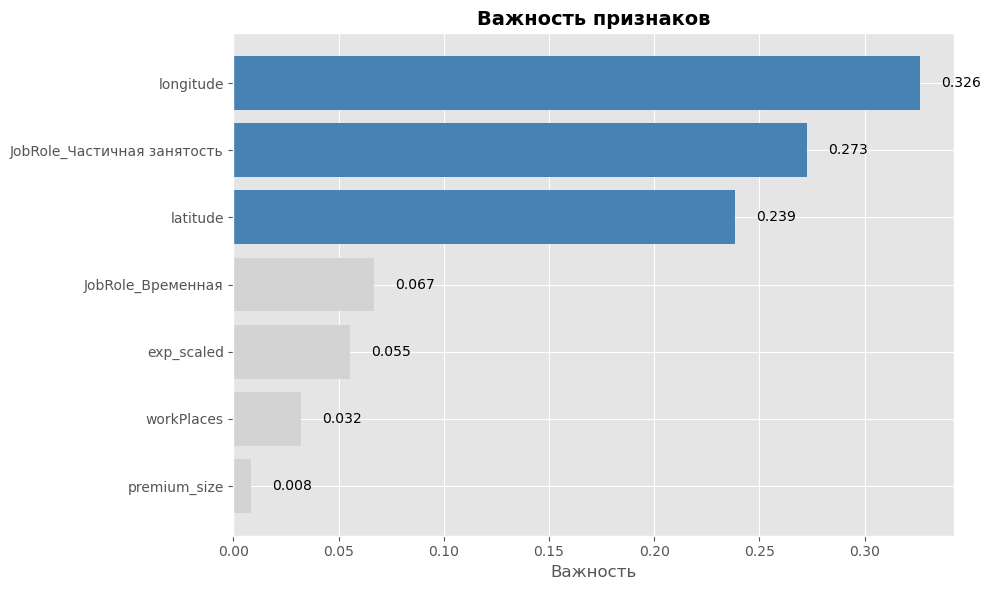

In [151]:
plt.figure(figsize=(10, 6))
colors = ['steelblue' if i < 3 else 'lightgray' for i in range(len(importance_rf))]
plt.barh(importance_rf['Признак'], importance_rf['Важность'], color=colors)
plt.xlabel('Важность', fontsize=12)
plt.title('Важность признаков', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

for i, (_, row) in enumerate(importance_rf.iterrows()):
    plt.text(row['Важность'] + 0.01, i, f"{row['Важность']:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

На часовую ставку школьников больше всего влияет географическое положение и тип занятости у вакансии. Опыт работы, количество мест и премии вносят незначительный вклад в размер ставки. Для повышения точности модели можно добавлять признаки, связанные с региональными особенностями вакансий.



Выводы всего исследования

Гипотеза 1:	Основу рынка составляют простые рабочие профессии	- подтвердилась, основа	уборщики и подсобные рабочие

Гипотеза 2:	Большинство вакансий не требуют опыта - подвтердилась, 93.6% вакансий не требуют опыт

Гипотеза 3: Частичная занятость дает более высокую часовую ставку - подтверждена, 329 руб/ч против 179 руб/ч

Гипотеза 4:	Существует региональная дифференциация зарплат - подтверждена, разрыв между регионами 44%

Гипотеза 5:	Стажировки предлагают наиболее высокую оплату - отвергнута кластеизацией, стажировки — 250 руб/ч, что ниже кластера 0 при более высоких требованиях к труду

Гипотеза 5: Зарплаты привязаны к МРОТ - подтверждена, медиана - 27 100 руб

Гипотеза 6:	Премии и бонусы характерны для высокооплачиваемых вакансий	- отвергнута регрессией, важность premium_size в модели регрессии — всего 0.8%

Гипотеза 7: Количество рабочих мест положительно коррелирует с зарплатой - отвергнута корреляциями,	важность рабочих мест и корреляция с зарплатой слабая отрицательная

Гипотеза 8:	Вакансии с гибким графиком имеют более высокую часовую ставку - подтверждена кластеризацией, кластер 0: 329 руб/ч

Гипотеза 9:	В восточных и северных регионах зарплаты выше	- подтверждена, longtude — важность 32.6% в модели

Гипотеза 10: Требования к образованию минимальны - подтверждена, требования NULL + MIDDLE больше 90% вакансий

Гипотеза 11: Крупный бизнес реже нанимает школьников	- подтверждена	даннымии и интервью, малый бизнес 61.6%

Гипотеза 12: Опыт работы является ключевым фактором, определяющим часовую ставку - отвергнута регрессией, важность exp_scaled всего 5.5%

На основе исследуемого датасета рынок труда для школьников составляет лишь 0.5% от общего числа вакансий на этом портале, однако 38% из них предлагают гибкие формы занятости, подходящие для совмещения с учебой, но не имеющиме явную маркировку подходящего для школьников. Ключевым инсайтом исследования стало, что частичная занятость обеспечивает часовую ставку 329 рублей, что на 84% выше, чем при полной занятости и той же деятельности. На основе кластеризации выделено 8 сегментов рынка, из которых целевыми для школьников являются кластеры 0 - частичная занятость и 1 - временные массовые позиции. Модели классификации и регрессии имели хорошее качество, логистическая регрессия достигла F1-скор 0.997, а случайный лес объясняет 52.4% дисперсии часовой ставки. Основными ограничениями исследования являются использование только данных с государственной платформы «Работа России» и временной срез за январь 2026 года, что не позволяет учесть сезонность и коммерческий сектор. Дальнейшие исследования могут быть иследованы с включением данных hh.ru и SuperJob, проведение интервью с работодателями, создания рекомендательного сервиса для подбора вакансий школьникам.